setting up the dataset


In [97]:
import numpy as np
import pandas as pd

# For reproducibility
np.random.seed(42)

# Feature names based on the paper
features = [
    "packet_rate",
    "byte_rate",
    "session_duration",
    "error_rate",
    "packet_size_avg",
    "traffic_volume",
    "port_usage_rate",
    "protocol_type",
    "traffic_entropy",
    "signal_strength"
]

print("Number of features:", len(features))

Number of features: 10


In [98]:
def generate_synthetic_network_data(n_samples=1000, contamination=0.1):
    """
    Generate synthetic network traffic data.
    
    Parameters:
    n_samples: total number of samples
    contamination: proportion of anomalous traffic
    
    Returns:
    X: feature dataframe
    y: labels, 0 = normal, 1 = anomaly
    """
    
    n_anomalies = int(n_samples * contamination)
    n_normal = n_samples - n_anomalies
    
    # Normal network traffic
    normal_data = np.random.normal(
        loc=0,
        scale=1,
        size=(n_normal, len(features))
    )
    
    # Anomalous network traffic
    anomalous_data = np.random.normal(
        loc=0.5,
        scale=1.2,
        size=(n_anomalies, len(features))
    )
    
    # Combine normal and anomalous data
    X = np.vstack([normal_data, anomalous_data])
    y = np.array([0] * n_normal + [1] * n_anomalies)
    
    # Shuffle dataset
    indices = np.random.permutation(n_samples)
    X = X[indices]
    y = y[indices]
    
    # Convert to dataframe
    X = pd.DataFrame(X, columns=features)
    
    return X, y

creating the synthetic network data


In [99]:
X, y = generate_synthetic_network_data(n_samples=1000, contamination=0.1)

df = X.copy()
df["label"] = y

df.head(30)

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength,label
0,-2.068376,0.089395,-0.442589,0.007728,0.945312,-0.552569,-1.873006,2.044482,-0.997228,-1.059037,0
1,-0.025027,0.817766,1.390208,0.557810,0.010353,-1.311836,-1.065114,-0.305225,-0.609512,-0.186971,0
2,0.438476,0.019617,0.672861,0.591814,-0.354041,-0.573602,0.101856,1.549020,-1.239107,-1.467525,0
3,-0.318748,-1.029812,-0.123344,0.309047,-0.655688,-0.235711,-0.939463,1.119245,-0.294456,1.452756,0
4,1.028769,0.501685,0.248325,0.078118,0.400236,0.201653,-1.029972,0.046079,-1.073689,0.081083,0
5,1.196631,-0.609783,-0.134017,0.014688,-0.784898,0.648280,-0.120948,0.419532,-0.887492,-0.437458,0
6,-1.178923,-0.219669,0.609526,-1.555374,0.200845,0.100791,0.041287,1.037159,0.334439,1.478072,0
7,0.854234,0.973858,-0.467812,-0.051064,0.288639,-1.340950,-1.525641,-0.220898,1.127025,-0.283765,1
8,0.012829,0.479827,-0.268646,-1.836360,-0.432774,0.793818,-0.297376,-0.246383,0.986377,-0.711973,0
9,0.891344,-0.204356,-0.290441,0.444145,0.815754,0.602473,1.040058,-1.018870,-0.227771,-0.940016,0


In [100]:
df["label"].value_counts()

label
0    900
1    100
Name: count, dtype: int64

### now we successfully created our artifitial dataset


## The overview of our created dataset :


In [101]:
df.describe()

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength,label
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.060222,0.083746,0.026157,0.004709,0.065059,0.016754,0.047206,0.056789,0.025495,0.090095,0.10000
std,1.037087,1.048611,1.011908,1.008869,1.046159,1.058922,1.063655,1.066161,1.015560,0.980805,0.30015
min,-4.206880,-3.688365,-3.241267,-2.943142,-3.138515,-3.170426,-2.862294,-3.601085,-3.007632,-3.176704,0.00000
25%,-0.606021,-0.610379,-0.680981,-0.720239,-0.625296,-0.715725,-0.690036,-0.696968,-0.633352,-0.536207,0.00000
50%,0.052989,0.052945,0.013400,0.046958,0.041611,0.034660,0.013466,0.023644,0.033525,0.067795,0.00000
75%,0.740190,0.772975,0.672435,0.708479,0.780684,0.716516,0.787006,0.757837,0.672273,0.751524,0.00000
max,3.076860,3.529055,3.536444,3.117681,3.098626,3.926238,3.243093,3.381900,3.822048,3.852731,1.00000


## It's time to standardize the dataset


In [102]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Standardize the feature data
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for better visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Show first rows
X_scaled_df.head()

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength
0,-2.053506,0.005390,-0.463462,0.002994,0.841835,-0.537914,-1.806199,1.865278,-1.007557,-1.172207
1,-0.082242,0.700343,1.348672,0.548514,-0.052319,-1.255291,-1.046275,-0.339719,-0.625591,-0.282630
2,0.364909,-0.061187,0.639413,0.582235,-0.400809,-0.557786,0.051406,1.400330,-1.245849,-1.588898
3,-0.365601,-1.062467,-0.147816,0.301814,-0.689290,-0.238537,-0.928086,0.997023,-0.315206,1.390023
4,0.934378,0.398763,0.219663,0.072800,0.320548,0.174698,-1.013221,-0.010051,-1.082884,-0.009194


In [103]:
# Show result
X_scaled_df.describe()

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,-2.042810e-17,7.105427e-17,1.598721e-17,5.861978e-17,-3.641532e-17,6.750156e-17,-2.842171e-17,-7.105427e-18,-1.776357e-17,-1.243450e-16
std,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,-4.116569e+00,-3.599044e+00,-3.230588e+00,-2.923397e+00,-3.063757e+00,-3.011342e+00,-2.736748e+00,-3.432600e+00,-2.988149e+00,-3.332398e+00
25%,-6.427402e-01,-6.622783e-01,-6.991658e-01,-7.189336e-01,-6.602255e-01,-6.920676e-01,-6.934685e-01,-7.073366e-01,-6.490769e-01,-6.388788e-01
50%,-6.978119e-03,-2.938788e-02,-1.261306e-02,4.189858e-02,-2.242485e-02,1.691800e-02,-3.173690e-02,-3.110403e-02,7.910449e-03,-2.274766e-02
75%,6.559800e-01,6.576059e-01,6.389922e-01,6.979322e-01,6.843921e-01,6.611560e-01,6.958741e-01,6.578726e-01,6.371866e-01,6.747101e-01
max,2.910218e+00,3.287236e+00,3.470712e+00,3.087150e+00,2.901170e+00,3.693795e+00,3.006131e+00,3.120330e+00,3.740254e+00,3.838192e+00


## Train Isolation Forest Model


In [104]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [105]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

model.fit(X_train)


IsolationForest(contamination=0.1, random_state=42)

In [106]:
print("Model training completed.")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Model training completed.
Training samples: 700
Testing samples: 300


In [107]:
# Predict anomalies on the test data
y_pred = model.predict(X_test)

# Show first 20 predictions
print(y_pred[:20])

[ 1  1  1  1 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]


In [108]:
# Convert model predictions to binary format
# sklearn: 1 = normal, -1 = anomaly
# our format: 0 = normal, 1 = anomaly

y_pred_binary = np.where(y_pred == -1, 1, 0)

print(y_pred_binary[:20])

[0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [109]:
unique, counts = np.unique(y_pred_binary, return_counts=True)

prediction_counts = dict(zip(unique, counts))
print(prediction_counts)

{0: 258, 1: 42}


## seeing the result


In [110]:
results_df = X_test.copy()

results_df["true_label"] = y_test
results_df["predicted_label"] = y_pred_binary

results_df.head(20)

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength,true_label,predicted_label
470,0.257120,0.206784,0.589330,-1.134056,0.931541,-0.087414,0.586268,-1.059138,-1.555835,0.742409,0,0
553,-0.517108,-0.868113,-0.705131,-1.344022,-0.134780,-1.607554,0.135178,-0.087385,0.119639,-0.624521,0,0
355,1.144028,-2.058166,-0.364686,-0.373029,-1.408302,-0.750734,-1.089038,1.591063,0.896686,1.205184,0,0
237,0.386075,-0.213044,0.228026,-0.231247,0.575733,-1.475645,-0.386143,0.225016,0.500664,1.431027,0,0
772,0.492385,0.843860,-0.353436,-0.611828,-1.100010,-0.795702,2.729589,1.114733,-1.356156,-1.440918,0,1
764,-2.469330,2.105928,-1.399769,-1.636419,0.915722,2.289320,1.257679,0.475888,0.560818,0.778648,0,1
825,1.827121,-0.562447,-1.072832,1.464703,1.814713,-0.012338,0.907004,1.205568,-0.756591,-0.586955,0,0
403,0.253686,1.145010,1.254524,0.535036,0.746669,0.469872,-0.478191,0.656679,-1.398933,0.983150,0,0
219,0.530267,-0.117999,0.760099,1.333274,0.949768,0.428722,-0.033245,-0.973677,0.703854,1.621573,0,0
540,0.681254,-0.474809,0.429740,-1.514376,0.700929,-0.540313,-0.032956,-0.140447,-1.277810,-1.268143,0,0


### These are the network traffic samples that the Isolation Forest model classified as anomalous.


In [111]:
results_df[results_df["predicted_label"] == 1].tail(20)

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength,true_label,predicted_label
317,-0.990697,-0.839444,0.075895,-2.299518,1.538187,0.401545,1.109776,-1.536553,1.200993,2.184404,0,1
512,-1.014516,-2.134495,-0.657620,-1.316784,1.508132,0.938275,-0.691694,2.060425,0.942090,-0.423259,0,1
205,-1.579461,-0.845894,-0.099001,-0.079708,1.824233,-1.325352,0.431167,1.344112,2.212649,-0.504422,0,1
780,-1.443352,-1.335349,0.251979,-2.119575,0.906222,-0.165258,3.006131,2.112489,-0.203875,-0.200377,0,1
207,-0.148431,1.185064,-1.298515,-1.390198,-0.620348,0.965261,-1.473538,-2.711026,-0.469586,0.470916,0,1
947,0.287605,-1.221563,-1.502535,-2.110999,0.627310,-0.530938,2.709060,-0.986409,-0.932904,-0.668651,0,1
14,0.856597,-0.371821,-1.248401,1.259199,-0.153400,1.619029,-2.156657,0.130077,1.865038,-0.452262,0,1
458,0.902362,1.545126,-1.645425,-1.776227,-0.657106,0.534758,0.422969,0.950596,-1.207024,-2.454557,0,1
95,-2.376970,1.248665,0.638852,-1.492699,-1.476457,1.564176,-0.738001,-0.836103,-2.257566,-0.449726,0,1
867,-2.217369,-2.103305,-0.625886,0.449220,-2.689812,-0.487990,-0.539405,1.249543,-0.404429,0.298775,0,1


In [112]:
results_df[(results_df["predicted_label"] == 1) & (results_df["true_label"] == 0)]

,packet_rate,byte_rate,session_duration,error_rate,packet_size_avg,traffic_volume,port_usage_rate,protocol_type,traffic_entropy,signal_strength,true_label,predicted_label
772,0.492385,0.843860,-0.353436,-0.611828,-1.100010,-0.795702,2.729589,1.114733,-1.356156,-1.440918,0,1
764,-2.469330,2.105928,-1.399769,-1.636419,0.915722,2.289320,1.257679,0.475888,0.560818,0.778648,0,1
855,-2.093506,1.197973,-0.704661,1.149056,0.959926,-1.230880,-1.068190,2.349519,1.699844,-0.124056,0,1
937,1.187125,2.389270,-1.212062,0.688452,-0.454135,0.724311,-1.427582,-1.238293,-0.789486,-0.011355,0,1
31,1.501901,-0.814981,1.104609,0.178656,0.178969,-1.877436,-2.116518,-0.260274,0.218128,-1.239697,0,1
506,-0.702865,-0.138178,-1.072370,-2.482009,0.129491,0.559482,0.202104,-1.882788,-0.370764,-2.354798,0,1
253,0.732723,-0.266408,0.268014,1.648757,-2.093513,0.374967,1.964383,0.211373,1.600980,-0.733751,0,1
347,-0.194807,0.757647,0.755982,-0.026517,-1.753182,2.811866,1.597796,0.624876,-0.767151,-0.207778,0,1
134,0.290549,1.387566,-0.061284,1.546995,-2.567629,0.760728,0.037476,-0.333885,0.065283,-2.119385,0,1
417,1.209766,0.600637,-1.040261,0.597582,1.341568,-0.044423,2.400115,-1.671175,0.658418,1.098048,0,1


---- and choose the anomaly wrong ones


In [113]:
print("Actual labels in test set:")
print(results_df["true_label"].value_counts())

print("\nPredicted labels by model:")
print(results_df["predicted_label"].value_counts())

Actual labels in test set:
true_label
0    270
1     30
Name: count, dtype: int64

Predicted labels by model:
predicted_label
0    258
1     42
Name: count, dtype: int64


### As seen here the model predicted the anomaly datas with a good percentage


# Evaluation Metrics


In [114]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_binary)*100

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Print results
print("Accuracy:", accuracy , "%")
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_binary, target_names=["Normal", "Anomaly"]))

Accuracy: 81.33333333333333 %

Confusion Matrix:
[[236  34]
 [ 22   8]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.87      0.89       270
     Anomaly       0.19      0.27      0.22        30

    accuracy                           0.81       300
   macro avg       0.55      0.57      0.56       300
weighted avg       0.84      0.81      0.83       300



# The Results


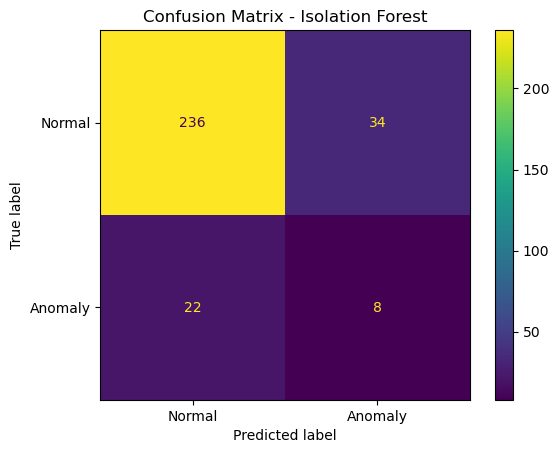

In [115]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot()
plt.title("Confusion Matrix - Isolation Forest")
plt.show()

# anomaly score


In [116]:
# Get anomaly scores
# decision_function gives higher scores for normal samples
scores = -model.decision_function(X_test)

print(scores[:10])

[-0.07580151 -0.06284556 -0.01016195 -0.08689334  0.01399297  0.04900544
 -0.00756162 -0.06641125 -0.05709169 -0.06289451]


# SDN alert and Policy Changes


In [117]:
# Alert and SDN policy simulation

alert_df = results_df[results_df["predicted_label"] == 1].copy()

total_alerts = len(alert_df)
true_alerts = len(alert_df[alert_df["true_label"] == 1])
false_alerts = len(alert_df[alert_df["true_label"] == 0])

print("Total alerts triggered:", total_alerts)
print("True anomaly alerts:", true_alerts)
print("False positive alerts:", false_alerts)

Total alerts triggered: 42
True anomaly alerts: 8
False positive alerts: 34


In [118]:
# Get anomaly scores
# Higher score means more anomalous
results_df["anomaly_score"] = -model.decision_function(X_test)
# Threshold for stronger policy action
high_risk_threshold = results_df["anomaly_score"].quantile(0.90)

In [119]:
def sdn_policy_action(row):
    if row["predicted_label"] == 0:
        return "No action"
    
    elif row["predicted_label"] == 1 and row["anomaly_score"] >= high_risk_threshold:
        return "Block or rate-limit suspicious flow"
    
    else:
        return "Generate alert and monitor flow"

results_df["sdn_policy_action"] = results_df.apply(sdn_policy_action, axis=1)

In [120]:
policy_summary = results_df["sdn_policy_action"].value_counts()
print(policy_summary)
print("\n")
results_df[results_df["predicted_label"] == 1][
    ["predicted_label", "anomaly_score", "sdn_policy_action"]
].head(20)

sdn_policy_action
No action                              258
Block or rate-limit suspicious flow     30
Generate alert and monitor flow         12
Name: count, dtype: int64




,predicted_label,anomaly_score,sdn_policy_action
772,1,0.013993,Block or rate-limit suspicious flow
764,1,0.049005,Block or rate-limit suspicious flow
855,1,0.029612,Block or rate-limit suspicious flow
438,1,0.019440,Block or rate-limit suspicious flow
54,1,0.022373,Block or rate-limit suspicious flow
937,1,0.002923,Generate alert and monitor flow
807,1,0.053888,Block or rate-limit suspicious flow
31,1,0.000666,Generate alert and monitor flow
506,1,0.020720,Block or rate-limit suspicious flow
253,1,0.015042,Block or rate-limit suspicious flow


other cases
